# 03 — Rolling Temporal Validation Split

**Goal:** Define and freeze the validation protocol that every model in the benchmark will use.

**Rules (from CLAUDE.md):**
- Preserve temporal order — do NOT shuffle.
- All model comparisons must use the same validation protocol and same evaluation metrics.
- Save every experiment output as an artifact.

**Design choices for this protocol:**
- Rolling-window splits over `time_s` — no random sampling.
- Splits aligned to **unique-timestamp boundaries** so tied `time_s` rows never split across train/val.
- Both targets must have non-zero rows in every fold (train AND val) — verified before saving.
- No preprocessing, scaling, or modelling in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42

DATA_PATH    = Path('../data/processed/ethylene_methane.parquet')
FIG_DIR      = Path('../results/figures')
TABLE_DIR    = Path('../results/tables')
MEMO_PATH    = Path('../results/memos/03_validation_split.md')
SPLITS_PATH  = TABLE_DIR / 'validation_splits.parquet'

for d in (FIG_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

SENSORS = [f's{i:02d}' for i in range(1, 17)]
TARGETS = ['methane_ppm', 'ethylene_ppm']
TIME    = 'time_s'

# Protocol parameters (locked once approved)
N_SPLITS    = 5      # number of (train, val) folds
WINDOW_KIND = 'rolling'  # 'rolling' (fixed train size) or 'expanding' (growing train)
VAL_FRAC    = 0.10   # fraction of dataset per validation window
TRAIN_FRAC  = 0.40   # fraction of dataset per training window (rolling only)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

## 1. Load Data & Verify Temporal Order

In [2]:
df = pd.read_parquet(DATA_PATH, columns=[TIME] + TARGETS)
n_rows = len(df)
print(f'Rows: {n_rows:,}')

assert df[TIME].is_monotonic_increasing, 'time_s must be monotonically increasing'
print(f'time_s monotonic: True')
print(f'time_s range    : {df[TIME].iloc[0]:.2f} -> {df[TIME].iloc[-1]:.2f}')

Rows: 4,178,504
time_s monotonic: True
time_s range    : 0.00 -> 41790.19


## 2. Build Timestamp Grid (Tie-Safe Split Boundaries)

Splitting on row indices alone could put tied-`time_s` rows on different sides of a boundary. Working with unique timestamps guarantees no leakage.

In [3]:
unique_times = df[TIME].drop_duplicates().to_numpy()
n_unique = len(unique_times)
print(f'Unique timestamps: {n_unique:,}')
print(f'Tied-timestamp rows: {n_rows - n_unique:,}')

Unique timestamps: 4,073,554
Tied-timestamp rows: 104,950


## 3. Generate Fold Boundaries

Rolling-window protocol: each fold has a fixed-size train window followed by a validation window. The window slides forward across the timeline.

In [4]:
def make_rolling_folds(unique_times, n_splits, train_frac, val_frac):
    """Rolling-window folds over unique timestamps."""
    n = len(unique_times)
    train_n = int(n * train_frac)
    val_n   = int(n * val_frac)
    # Step size so that all folds fit in the timeline
    total_span = train_n + val_n
    if n_splits > 1:
        step = (n - total_span) // (n_splits - 1)
    else:
        step = 0
    folds = []
    for k in range(n_splits):
        t_start = k * step
        t_end   = t_start + train_n
        v_start = t_end
        v_end   = v_start + val_n
        folds.append({
            'fold': k + 1,
            'train_time_start': float(unique_times[t_start]),
            'train_time_end'  : float(unique_times[t_end - 1]),
            'val_time_start'  : float(unique_times[v_start]),
            'val_time_end'    : float(unique_times[v_end - 1]),
        })
    return folds

def make_expanding_folds(unique_times, n_splits, val_frac):
    """Expanding-window folds (TimeSeriesSplit-style) over unique timestamps."""
    n = len(unique_times)
    val_n = int(n * val_frac)
    folds = []
    for k in range(n_splits):
        v_end   = n - (n_splits - 1 - k) * val_n
        v_start = v_end - val_n
        t_start = 0
        t_end   = v_start
        folds.append({
            'fold': k + 1,
            'train_time_start': float(unique_times[t_start]),
            'train_time_end'  : float(unique_times[t_end - 1]),
            'val_time_start'  : float(unique_times[v_start]),
            'val_time_end'    : float(unique_times[v_end - 1]),
        })
    return folds

if WINDOW_KIND == 'rolling':
    folds = make_rolling_folds(unique_times, N_SPLITS, TRAIN_FRAC, VAL_FRAC)
else:
    folds = make_expanding_folds(unique_times, N_SPLITS, VAL_FRAC)

for f in folds:
    print(f)

{'fold': 1, 'train_time_start': 0.0, 'train_time_end': 16648.44, 'val_time_start': 16648.45, 'val_time_end': 20722.07}
{'fold': 2, 'train_time_start': 5390.17, 'train_time_end': 21740.52, 'val_time_start': 21740.53, 'val_time_end': 25935.24}
{'fold': 3, 'train_time_start': 10534.11, 'train_time_end': 26953.69, 'val_time_start': 26953.7, 'val_time_end': 31027.3}
{'fold': 4, 'train_time_start': 15630.06, 'train_time_end': 32045.81, 'val_time_start': 32045.82, 'val_time_end': 36365.86}
{'fold': 5, 'train_time_start': 20722.08, 'train_time_end': 37438.94, 'val_time_start': 37438.95, 'val_time_end': 41790.17}


## 4. Map Time Boundaries to Row Indices

In [5]:
time_arr = df[TIME].to_numpy()

def time_to_row_range(t_start, t_end):
    """Return (start_idx, end_idx) where end_idx is EXCLUSIVE."""
    start = int(np.searchsorted(time_arr, t_start, side='left'))
    end   = int(np.searchsorted(time_arr, t_end,   side='right'))  # include all tied rows
    return start, end

records = []
for f in folds:
    tr_s, tr_e = time_to_row_range(f['train_time_start'], f['train_time_end'])
    va_s, va_e = time_to_row_range(f['val_time_start'],   f['val_time_end'])
    records.append({
        'fold': f['fold'],
        'split': 'train',
        'start_idx': tr_s, 'end_idx': tr_e,
        'start_time_s': f['train_time_start'], 'end_time_s': f['train_time_end'],
        'n_rows': tr_e - tr_s,
    })
    records.append({
        'fold': f['fold'],
        'split': 'val',
        'start_idx': va_s, 'end_idx': va_e,
        'start_time_s': f['val_time_start'], 'end_time_s': f['val_time_end'],
        'n_rows': va_e - va_s,
    })

splits_df = pd.DataFrame(records)
print(splits_df.to_string(index=False))

 fold split  start_idx  end_idx  start_time_s  end_time_s  n_rows
    1 train          0  1664421          0.00    16648.44 1664421
    1   val    1664421  2071788      16648.45    20722.07  407367
    2 train     538982  2173632       5390.17    21740.52 1634650
    2   val    2173632  2593081      21740.53    25935.24  419449
    3 train    1053365  2694922      10534.11    26953.69 1641557
    3   val    2694922  3102284      26953.70    31027.30  407362
    4 train    1562582  3204123      15630.06    32045.81 1641541
    4   val    3204123  3636095      32045.82    36365.86  431972
    5 train    2071788  3743404      20722.08    37438.94 1671616
    5   val    3743404  4178502      37438.95    41790.17  435098


## 5. Verification — Leakage & Coverage

In [6]:
checks = []
for f in folds:
    fold_id = f['fold']
    tr = splits_df[(splits_df.fold == fold_id) & (splits_df.split == 'train')].iloc[0]
    va = splits_df[(splits_df.fold == fold_id) & (splits_df.split == 'val')].iloc[0]

    # 1. No row-index overlap
    no_row_overlap = tr['end_idx'] <= va['start_idx']

    # 2. No time overlap
    no_time_overlap = tr['end_time_s'] < va['start_time_s']

    # 3. Both targets have non-zero rows in train and val
    tr_slice = df.iloc[tr['start_idx']:tr['end_idx']]
    va_slice = df.iloc[va['start_idx']:va['end_idx']]
    tr_meth_nz = (tr_slice['methane_ppm']  > 0).sum()
    tr_eth_nz  = (tr_slice['ethylene_ppm'] > 0).sum()
    va_meth_nz = (va_slice['methane_ppm']  > 0).sum()
    va_eth_nz  = (va_slice['ethylene_ppm'] > 0).sum()
    targets_present = all(x > 0 for x in [tr_meth_nz, tr_eth_nz, va_meth_nz, va_eth_nz])

    checks.append({
        'fold': fold_id,
        'train_rows': tr['n_rows'],
        'val_rows': va['n_rows'],
        'no_row_overlap': no_row_overlap,
        'no_time_overlap': no_time_overlap,
        'tr_methane_nonzero': tr_meth_nz,
        'tr_ethylene_nonzero': tr_eth_nz,
        'va_methane_nonzero': va_meth_nz,
        'va_ethylene_nonzero': va_eth_nz,
        'targets_present_all_folds': targets_present,
    })

checks_df = pd.DataFrame(checks)
print(checks_df.to_string(index=False))

all_passed = (
    checks_df['no_row_overlap'].all() and
    checks_df['no_time_overlap'].all() and
    checks_df['targets_present_all_folds'].all()
)
print(f'\nAll verification checks passed: {all_passed}')
assert all_passed, 'Verification failed — review fold construction before proceeding.'

 fold  train_rows  val_rows  no_row_overlap  no_time_overlap  tr_methane_nonzero  tr_ethylene_nonzero  va_methane_nonzero  va_ethylene_nonzero  targets_present_all_folds
    1     1664421    407367            True             True              809569               686487              226902               177001                       True
    2     1634650    419449            True             True              795778               671520              218023               273968                       True
    3     1641557    407362            True             True              723460               735888              194761                77500                       True
    4     1641541    431972            True             True              813971               646077               87018               219185                       True
    5     1671616    435098            True             True              684382               784770              128899               154702        

## 6. Fold Layout Visualisation

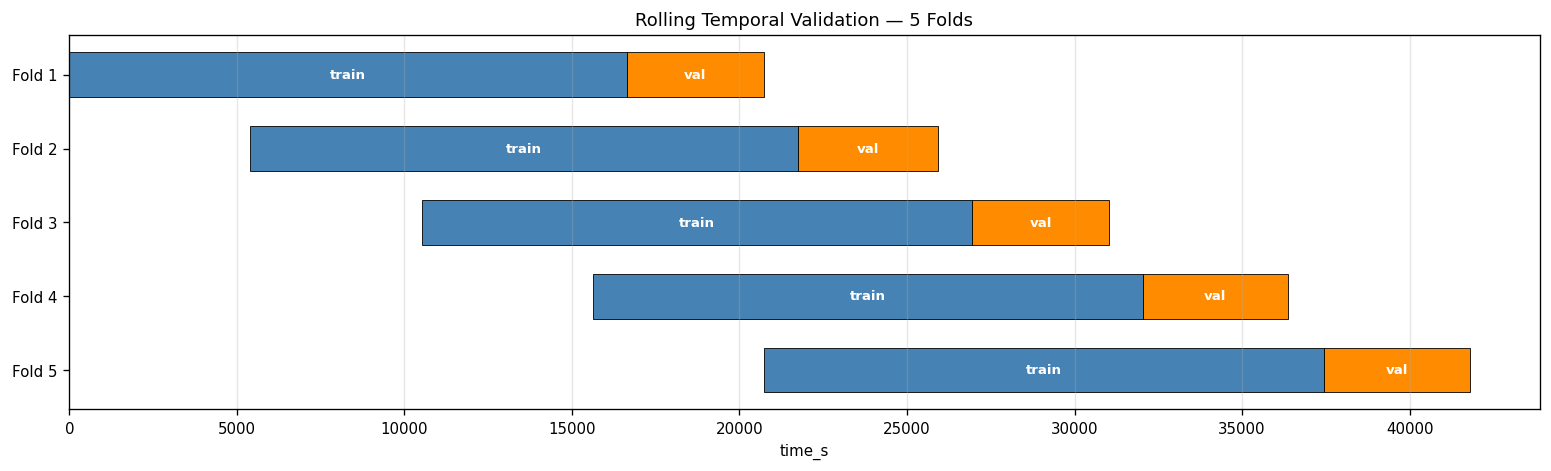

Saved: 03_fold_layout.png


In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
y_positions = {fold_id: -fold_id for fold_id in checks_df['fold']}

for _, row in splits_df.iterrows():
    y = y_positions[row['fold']]
    color = 'steelblue' if row['split'] == 'train' else 'darkorange'
    ax.barh(y, row['end_time_s'] - row['start_time_s'],
            left=row['start_time_s'], height=0.6, color=color, edgecolor='black', linewidth=0.5)
    ax.text(row['start_time_s'] + (row['end_time_s'] - row['start_time_s']) / 2, y,
            row['split'], ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels([f'Fold {f}' for f in y_positions])
ax.set_xlabel('time_s')
ax.set_title(f'{WINDOW_KIND.title()} Temporal Validation — {N_SPLITS} Folds')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_fold_layout.png', bbox_inches='tight')
plt.show()
print('Saved: 03_fold_layout.png')

## 7. Save Fold Boundaries as Artifact

In [8]:
splits_df.to_parquet(SPLITS_PATH, index=False)
print(f'Saved fold boundaries to: {SPLITS_PATH}')
print('\nReload with:')
print(f"  splits_df = pd.read_parquet('{SPLITS_PATH.as_posix()}')")
print('  # For each fold:')
print("  #   train = df.iloc[row.start_idx:row.end_idx]  (where row.split == 'train')")
print("  #   val   = df.iloc[row.start_idx:row.end_idx]  (where row.split == 'val')")

Saved fold boundaries to: ..\results\tables\validation_splits.parquet

Reload with:
  splits_df = pd.read_parquet('../results/tables/validation_splits.parquet')
  # For each fold:
  #   train = df.iloc[row.start_idx:row.end_idx]  (where row.split == 'train')
  #   val   = df.iloc[row.start_idx:row.end_idx]  (where row.split == 'val')


## 8. Save Memo

In [9]:
MEMO_PATH.parent.mkdir(parents=True, exist_ok=True)

# Inline markdown-table builder so we don't depend on `tabulate`.
def df_to_md(t):
    header = '| ' + ' | '.join(t.columns) + ' |'
    sep    = '| ' + ' | '.join(['---'] * len(t.columns)) + ' |'
    rows   = ['| ' + ' | '.join(str(v) for v in row) + ' |'
              for row in t.itertuples(index=False)]
    return '\n'.join([header, sep, *rows])

summary_md = df_to_md(checks_df[['fold', 'train_rows', 'val_rows',
                                 'tr_methane_nonzero', 'tr_ethylene_nonzero',
                                 'va_methane_nonzero', 'va_ethylene_nonzero']])

lines = [
    '# 03 — Validation Split Protocol',
    '',
    f'**Date:** 2026-05-18',
    f'**Dataset:** {DATA_PATH.as_posix()}',
    f'**Artifact:** {SPLITS_PATH.as_posix()}',
    '',
    '---',
    '',
    '## Protocol',
    f'- Window kind: **{WINDOW_KIND}**',
    f'- Number of folds: **{N_SPLITS}**',
    f'- Train fraction (per fold): {TRAIN_FRAC}',
    f'- Validation fraction (per fold): {VAL_FRAC}',
    f'- Split boundaries aligned to unique timestamps (tie-safe)',
    f'- No shuffling, no random sampling, temporal order preserved',
    '',
    '## Verification',
    f'- All folds have non-overlapping train/val row ranges: {bool(checks_df["no_row_overlap"].all())}',
    f'- All folds have non-overlapping train/val time ranges: {bool(checks_df["no_time_overlap"].all())}',
    f'- Both targets have non-zero rows in train and val for every fold: {bool(checks_df["targets_present_all_folds"].all())}',
    '',
    '## Fold Summary',
    '',
    summary_md,
    '',
    '## Usage',
    '',
    '```python',
    'splits_df = pd.read_parquet("results/tables/validation_splits.parquet")',
    'for fold_id in splits_df.fold.unique():',
    '    tr = splits_df.query("fold == @fold_id and split == \\"train\\"").iloc[0]',
    '    va = splits_df.query("fold == @fold_id and split == \\"val\\"").iloc[0]',
    '    train = df.iloc[tr.start_idx:tr.end_idx]',
    '    val   = df.iloc[va.start_idx:va.end_idx]',
    '    # ... fit on train, evaluate on val ...',
    '```',
    '',
    '## Next Step',
    '',
    'Notebook `04_preprocessing.ipynb`: define scaling/transform pipeline that fits on **training fold only** and applies to validation fold. No leakage.',
]

MEMO_PATH.write_text('\n'.join(lines), encoding='utf-8')
print(f'Memo saved to {MEMO_PATH}')

Memo saved to ..\results\memos\03_validation_split.md
